In [1]:
import RestrictedBoltzmannMachines as RBMs
using FASTX
using CairoMakie
CairoMakie.activate!()
using StatsBase

# Clustering sequences using Restricted Boltzmann Machines

*Written by Shoichi Yip. Last updated: 20 August 2026.*

One way to cluster protein sequences is with the use of **Restricted Boltzmann Machines** (or RBM). They are neural networks and they are usually made of a *visible layer* and a *hidden layer*.

In order to use an RBM in order to cluster sequences, we can create an RBM made of a visible layer with $L$ Potts nodes (each node can have one among $q$ colors) and a hidden layer with one Potts nodes that can take $k$ colors (each one of the $k$ colors represents a cluster).

As an output, we get for each sequence a score for each of the $k$ colors. The `argmax` of this vector will yield the cluster the sequence belongs to.

## Importing the sequences

First of all, let us import the sequences of the alignment.

In [2]:
reader = open(FASTA.Reader, "../data/iter_aln_v2.faa")

descriptions = String[]
sequences = String[]

for record in reader
    push!(descriptions, String(description(record)))
    push!(sequences, String(sequence(record)))
end

Let us also import the indices of the red sector.

In [3]:
using DelimitedFiles

red_sector = vec(Int.(readdlm("../data/iter_aln_v2_redsector.txt")))
red_sector_ordered = sort(copy(red_sector))

17-element Vector{Int64}:
   2
 165
 177
 189
 192
 193
 197
 198
 201
 204
 228
 229
 233
 235
 241
 242
 243

We can convert the alignment to a format which is compatible with the RBM package.

RBM wants as an input a one-hot encoded alignment as an array of size $q \times L \times M$.

In [4]:
alphabet = collect("ACDEFGHIKLMNPQRSTVWY-")
aa2int = Dict(aa => i for (i, aa) in enumerate(alphabet))

nseq = length(sequences)
L = length(first(sequences))
q = length(alphabet)

alignment = falses(q, L, nseq)

for i in 1:nseq
    @assert length(sequences[i]) == L "Sequences have different lengths"

    for j in 1:L
        aa = sequences[i][j]
        k = get(aa2int, aa, 0)

        k == 0 && throw(ArgumentError("Invalid character $aa at sequence $i, position $j"))

        alignment[k, j, i] = true
    end
end

We can define the alignment made just of the subset of residues of the red sector.

In [5]:
alignment_sector = alignment[:, red_sector_ordered, :]

21×17×89439 BitArray{3}:
[:, :, 1] =
 0  0  0  0  0  1  1  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 

## Cluster the sequences and measure their entropy

We can try now to cluster the sequences using RBMs that have $k$ hidden layers.

For each RBM with $k$ hidden nodes:
- we will train the RBM
- we will assign cluster labels to each sequence
- we will compute the entropy of the cluster label counts

Doing this for each value of $k$ will allow us to evaluate which is the right $k^*$ cutoff value. We expect that for low $k$ we will have a pretty homogeneous distribution of sequences in clusters, while at high $k$ we will have a prolieferation of small clusters. The sweet spot will be in the middle of these two regimes.

We will replicate the process for 5 times in order to have enough statistics because the RBM has stochasticity.

We can define the functions for computing the cluster labels and the entropy.

In [6]:
function get_entropy(occurrences)
    frequencies = occurrences ./ sum(occurrences)
    sum(- frequencies .* log.(frequencies .+ eps()))
end

function seq_cluster(rbm, sequence)
    argmax(RBMs.mean_h_from_v(rbm, sequence)[:])
end

seq_cluster (generic function with 1 method)

Now we can loop through values of $k$.

2
5
10
25
50
75
100
250
500
750
1000


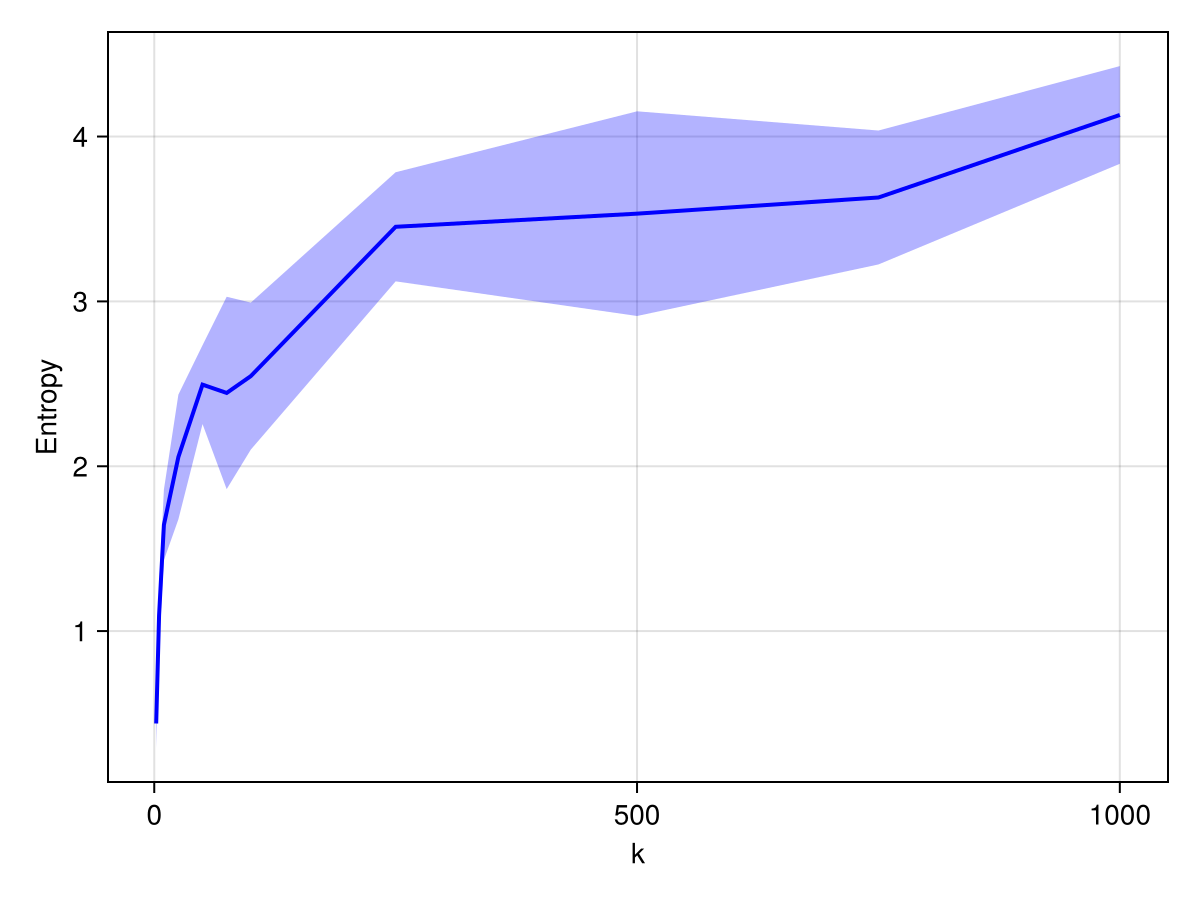

In [7]:
ks = [2, 5, 10, 25, 50, 75, 100, 250, 500, 750, 1000]
n_reps = 5

entropies = map(ks) do k
    reps = [begin
        Theta_visible = randn(size(alignment_sector)[[1, 2]]...)
        visible = RBMs.Potts(; θ = Theta_visible)
        Theta_hidden = randn(k, 1)
        hidden = RBMs.Potts(; θ = Theta_hidden)
        weights = randn((size(visible)..., size(hidden)...)...)
        rbm = RBMs.RBM(visible, hidden, weights)
        RBMs.pcd!(rbm, alignment_sector)
        labels = seq_cluster.(Ref(rbm), eachslice(alignment_sector, dims=3))
        get_entropy(counts(labels, k))
    end for _ in 1:n_reps]
    println(k)
    (mean(reps), std(reps))
end

entropies_mean = first.(entropies)
entropies_std  = last.(entropies)

fig = Figure()
ax  = Axis(fig[1, 1], xlabel="k", ylabel="Entropy")

band!(ax, ks, entropies_mean .- entropies_std, entropies_mean .+ entropies_std,
      color=(:blue, 0.3))
lines!(ax, ks, entropies_mean, color=:blue, linewidth=2)

fig

Actually we can also show the softmax values for each sequence using a code like the following.

In [8]:
# heatmap(RBMs.mean_h_from_v(rbm, alignment_sector[:, :, 2560]))

We can then export the assignments of the clustering by writing a text file containing a label for each sequence.

In [10]:
k = 100

Theta_visible = randn(size(alignment_sector)[[1, 2]]...)
visible = RBMs.Potts(; θ = Theta_visible)
Theta_hidden = randn(k, 1)
hidden = RBMs.Potts(; θ = Theta_hidden)
weights = randn((size(visible)..., size(hidden)...)...)
rbm = RBMs.RBM(visible, hidden, weights)
RBMs.pcd!(rbm, alignment_sector)
labels = seq_cluster.(Ref(rbm), eachslice(alignment_sector, dims=3))

labels_vec = Int.(labels)  # ensure integer type

open("../data/clusters_rbm_k100.txt", "w") do io
    for l in labels_vec
        println(io, l)
    end
end